# Random TIFF Band Viewer

This notebook samples a few random TIFF images and plots:
- RGB composite (when red/green/blue bands are available)
- Every other band as its own grayscale panel with band name labels


In [1]:
from __future__ import annotations

import random
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import rasterio


In [2]:
# ---- Configuration ----
PROJECT_ROOT = Path.cwd()
tiff_root = PROJECT_ROOT / 'data' / 'sat_images'

sample_count = 5
random_seed = 42

print('tiff_root:', tiff_root.resolve())


tiff_root: C:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images


In [5]:
def normalize_name(name: str) -> str:
    return ''.join(ch for ch in name.lower() if ch.isalnum())


def band_aliases() -> dict[str, Tuple[str, ...]]:
    return {
        'blue': ('blue', 'b', 'band2', 'b2'),
        'green': ('green', 'g', 'band3', 'b3'),
        'red': ('red', 'r', 'band4', 'b4'),
    }


def extract_band_names(src: rasterio.io.DatasetReader) -> List[str]:
    names: List[str] = []
    for i in range(1, src.count + 1):
        desc = src.descriptions[i - 1] if src.descriptions else None
        tags = src.tags(i)
        tag_name = tags.get('name') or tags.get('band_name') or tags.get('long_name')
        chosen = (desc or tag_name or f'band{i}').strip()
        names.append(chosen)
    return names


def find_band_index(band_names: List[str], key: str) -> int:
    aliases = tuple(normalize_name(a) for a in band_aliases()[key])
    normalized = [normalize_name(n) for n in band_names]

    for idx, name in enumerate(normalized):
        if name in aliases:
            return idx

    for idx, name in enumerate(normalized):
        if any(alias in name for alias in aliases):
            return idx

    raise ValueError(f"Could not find band '{key}' in names: {band_names}")


def stretch_for_display(arr: np.ndarray, lo: float = 2.0, hi: float = 98.0) -> np.ndarray:
    arr = arr.astype(np.float32)
    vmin = np.nanpercentile(arr, lo)
    vmax = np.nanpercentile(arr, hi)
    if vmax <= vmin:
        vmax = vmin + 1.0
    out = (arr - vmin) / (vmax - vmin)
    return np.clip(out, 0.0, 1.0)


def rgb_panel(data: np.ndarray, names: List[str]) -> tuple[np.ndarray, tuple[int, int, int]]:
    r_idx = find_band_index(names, 'red')
    g_idx = find_band_index(names, 'green')
    b_idx = find_band_index(names, 'blue')

    rgb = np.stack([data[r_idx], data[g_idx], data[b_idx]], axis=-1)
    rgb = stretch_for_display(rgb)
    return rgb, (r_idx, g_idx, b_idx)


In [6]:
def discover_tiffs(root: Path) -> List[Path]:
    files = sorted(list(root.glob('**/*.tif')) + list(root.glob('**/*.tiff')))
    return files


all_tiffs = discover_tiffs(tiff_root)
print(f'Found {len(all_tiffs)} TIFF files under {tiff_root}.')

if not all_tiffs:
    raise RuntimeError('No TIFF files found. Update tiff_root to your data folder.')

n = min(sample_count, len(all_tiffs))
rng = random.Random(random_seed)
selected = rng.sample(all_tiffs, k=n)

print('Selected files:')
for p in selected:
    print('-', p)


Found 4546 TIFF files under c:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images.
Selected files:
- c:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images\australianarrabeen\bilinear\S2\S2_20190819_235251.tif
- c:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images\australianarrabeen\bicubic\L8\L8_20130817_089083.tif
- c:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images\hawaiiwaikiki\bicubic\S2\S2_20201025_211919.tif
- c:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images\hawaiiwaikiki\bicubic\L8\L8_20180901_064045.tif
- c:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images\francetrucvert\bilinear\L8\L8_20150909_201029.tif


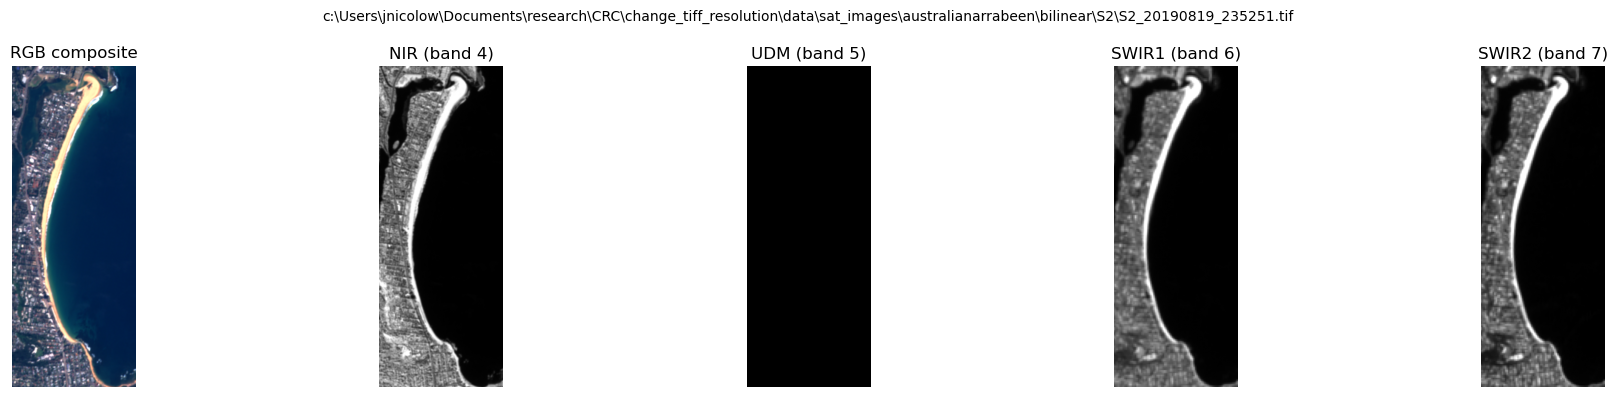

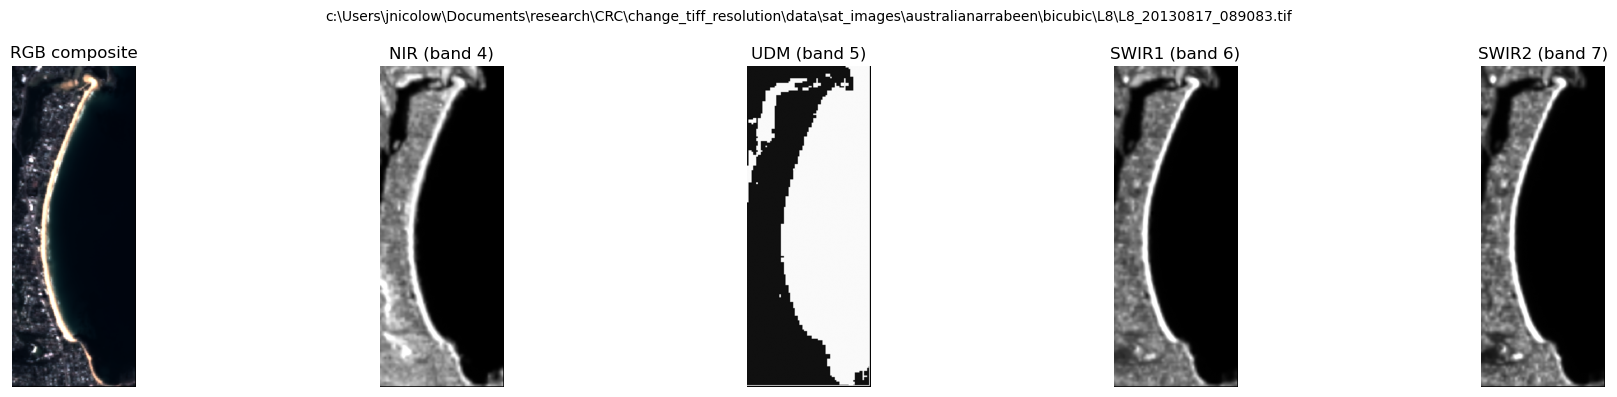

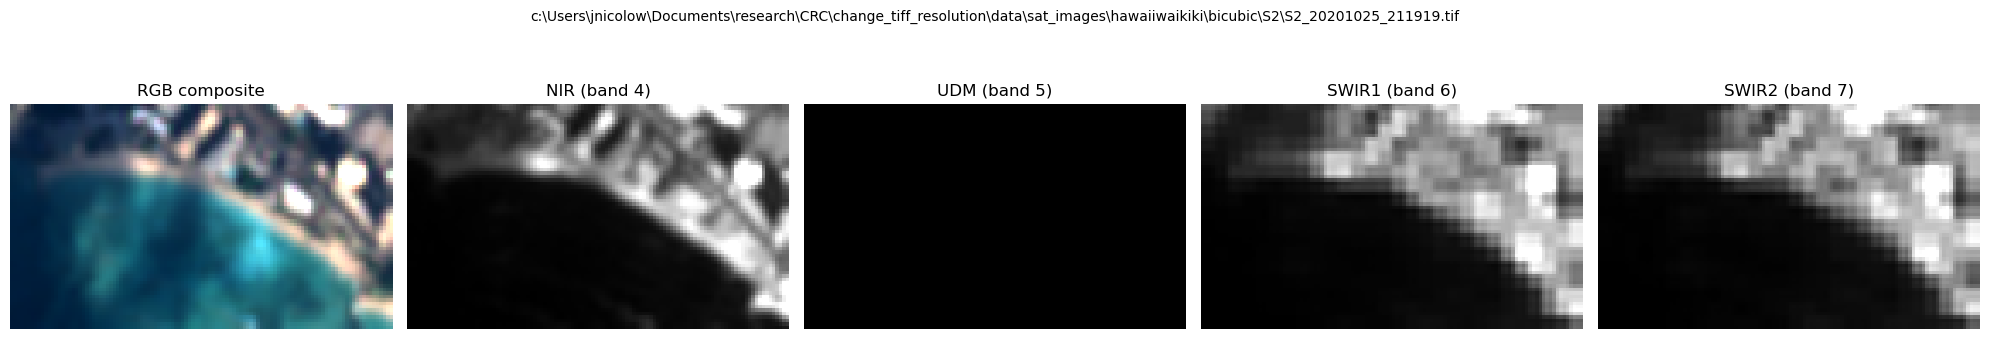

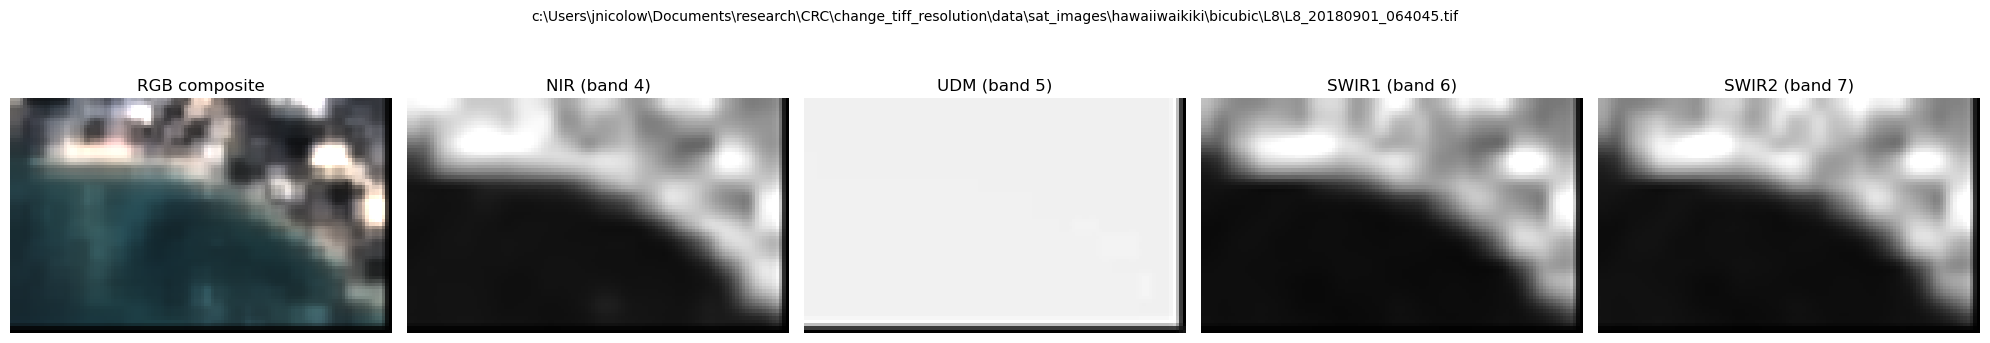

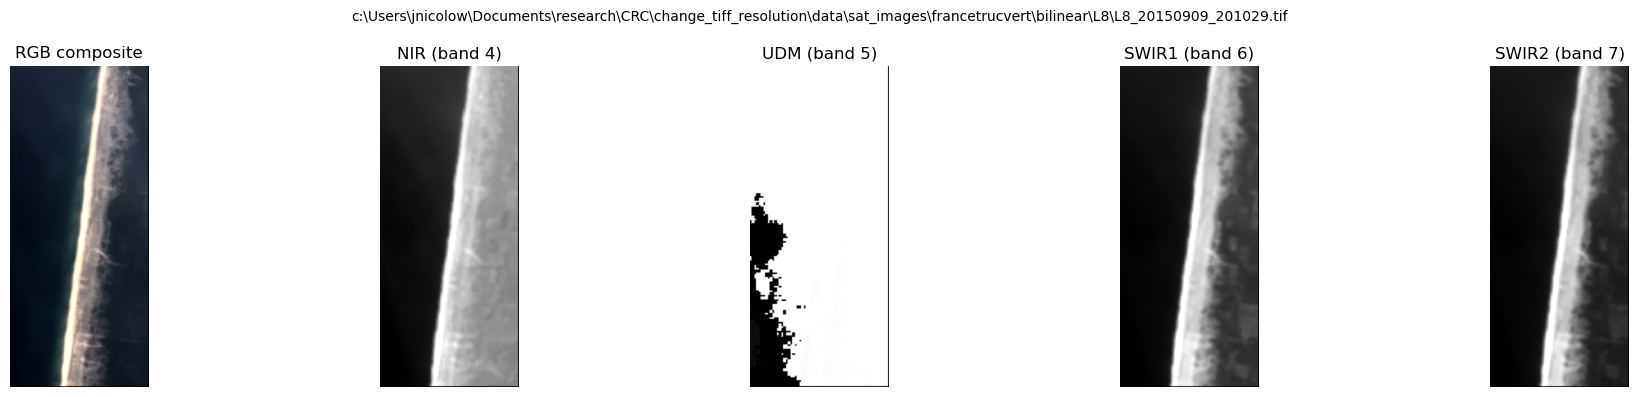

In [7]:
for scene_path in selected:
    with rasterio.open(scene_path) as src:
        data = src.read().astype(np.float32)  # shape: (bands, H, W)
        names = extract_band_names(src)

    rgb = None
    rgb_indices: tuple[int, int, int] | None = None
    try:
        rgb, rgb_indices = rgb_panel(data, names)
    except Exception:
        rgb = None
        rgb_indices = None

    non_rgb_indices = list(range(data.shape[0]))
    if rgb_indices is not None:
        non_rgb_indices = [i for i in non_rgb_indices if i not in rgb_indices]

    total_panels = (1 if rgb is not None else 0) + len(non_rgb_indices)
    fig, axes = plt.subplots(1, total_panels, figsize=(4 * total_panels, 4), squeeze=False)
    ax_list = axes[0]

    col = 0
    if rgb is not None:
        ax_list[col].imshow(rgb)
        ax_list[col].set_title('RGB composite')
        ax_list[col].axis('off')
        col += 1

    for i in non_rgb_indices:
        band_img = stretch_for_display(data[i])
        ax_list[col].imshow(band_img, cmap='gray')
        ax_list[col].set_title(f"{names[i]} (band {i + 1})")
        ax_list[col].axis('off')
        col += 1

    fig.suptitle(str(scene_path), fontsize=10)
    plt.tight_layout()
    plt.show()
